# House Price Prediction
- Problema: Regressão (previsão de valores contínuos)
- Modelos Treinados: Regressão Linear e KNN (KNeighborsRegressor).
- Objetivo: Treinar um modelo capaz de prever

## 0. Importação do Dataset

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("debayank2024/house-price-prediction")

print("Path to dataset files:", path)

Path to dataset files: /home/leo/.cache/kagglehub/datasets/debayank2024/house-price-prediction/versions/1


In [14]:
df = pd.read_csv(f"{path}/modified_data.csv")

---
## 1. Análise Exploratória

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   object 
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   object 
 15  city            4600 non-null   object 
 16  statezip        4600 non-null   object 
 17  price_per_sqft  4600 non-null   f

Colunas:
- data = data da cotação da casa
- price (y)= preço da casa
- bedrooms = quantidade de quartos
- bathrooms = quantidade de banheiros
  - por que está em float? a quantidade de banheiros não deveria ser um numero inteiro?
- sqft_living = metros quadrados
- sqft_lot = área do terreno
- floors = andares
- waterfront = BOOLEANO se tem uma orla
- view = vistas
- condition = condição do local
- sqft_above = área acima do solo
- sqft_basement = área do porão
- yr_built = ano de construção
- yr_renovated = ano de renovação [SE ESTIVER ZERADO, NÃO HOUVE RENOVAÇÃO DO IMÓVEL]
- street = rua do imóvel
- price_per_sqrt(datalakage) = preço por metro quadrado

In [16]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


In [17]:
df['city'].nunique()

44

Se eu fosse fazer um one-hot-enconder para essa coluna, já seriam mais 43 colunas para o dataset.

In [18]:
colunas_numericas = df.select_dtypes(include = ['int64', 'float64'])
colunas_numericas = list(colunas_numericas)

colunas_numericas.remove('price')
colunas_numericas.remove('price_per_sqft')


for i in colunas_numericas:
  print(i)

bedrooms
bathrooms
sqft_living
sqft_lot
floors
waterfront
view
condition
sqft_above
sqft_basement
yr_built
yr_renovated


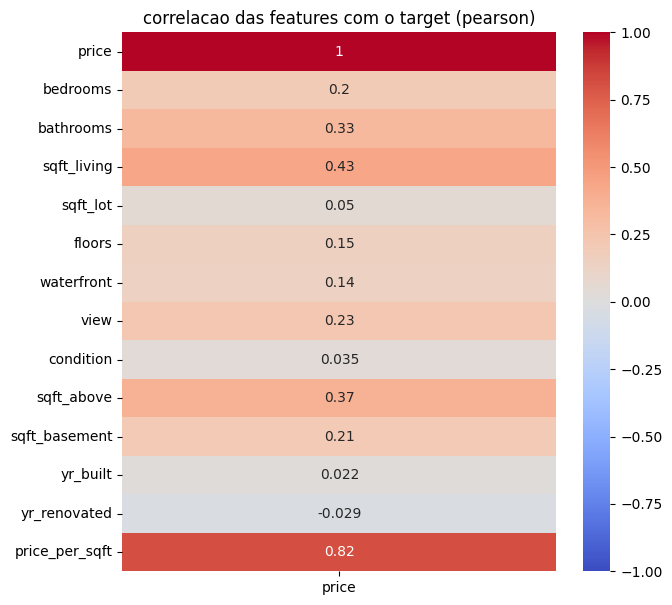

In [19]:
df_numerico = df.select_dtypes(include = ['int64', 'float64'])


plt.figure(figsize=(7,7))

sns.heatmap(df_numerico.corr()[['price']], annot= True, cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.title('correlacao das features com o target (pearson)')

plt.show()

Como interpretar?

| Correlação | Interpretação                          |
| ---------: | -------------------------------------- |
|       `+1` | Relação linear positiva perfeita       |
|     `+0.7` | Relação linear positiva forte          |
|     `+0.3` | Relação linear positiva fraca/moderada |
|        `0` | Sem relação linear                     |
|     `-0.3` | Relação linear negativa fraca/moderada |
|     `-0.7` | Relação linear negativa forte          |
|       `-1` | Relação linear negativa perfeita       |

Seguindo essa lógica, as features que mais tem correlação com o Target são:
- quanto maior o sqft_living (metros quadrados) maior o preço
- quanto maior o sqft_above (metros quadrados sobre o solo) maior o preço
- quanto mais bathrooms (banheiros) maior o preço

Abaixo, as mesmas informações mas sem plot

In [20]:
df_numerico.corr()['price'].sort_values()

yr_renovated     -0.028774
yr_built          0.021857
condition         0.034915
sqft_lot          0.050451
waterfront        0.135648
floors            0.151461
bedrooms          0.200336
sqft_basement     0.210427
view              0.228504
bathrooms         0.327110
sqft_above        0.367570
sqft_living       0.430410
price_per_sqft    0.819279
price             1.000000
Name: price, dtype: float64

Correlação de spearmen

In [21]:
df_numerico.corr(method ='spearman')['price'].sort_values()

yr_renovated     -0.070935
condition         0.023843
sqft_lot          0.075483
waterfront        0.083184
yr_built          0.084415
sqft_basement     0.236591
view              0.267564
floors            0.320929
bedrooms          0.337863
bathrooms         0.492451
sqft_above        0.534038
price_per_sqft    0.600178
sqft_living       0.631264
price             1.000000
Name: price, dtype: float64

#### Qual a diferença entre Pearson e Spearmen?
- Pearson busca uma correlação Linear, como uma reta.

- Spearmen busca uma correlação Não Linear, como anéis em plots

exemplo: "Se X aumenta, o Y diminui?"


Vamos fazer um scatterplot

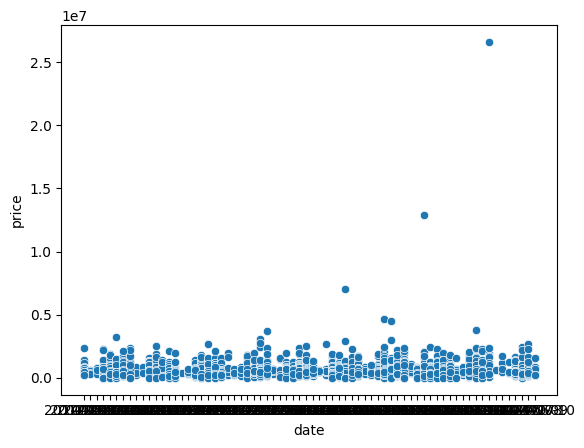

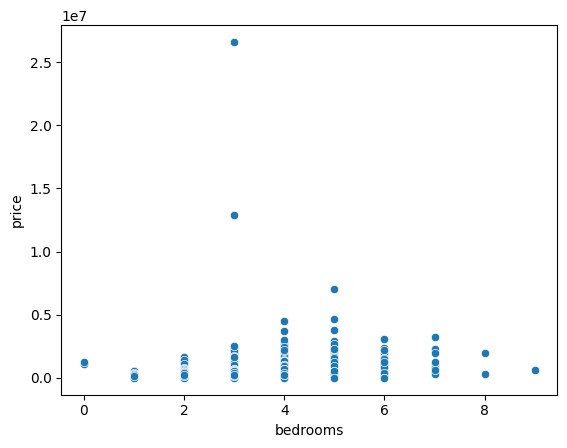

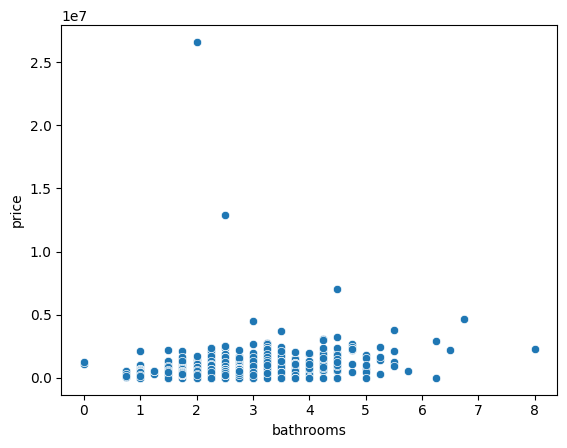

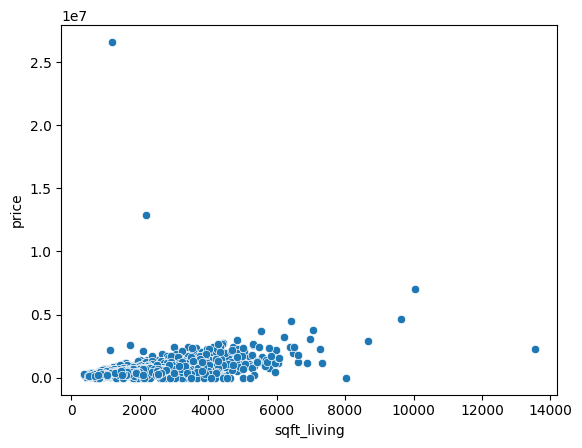

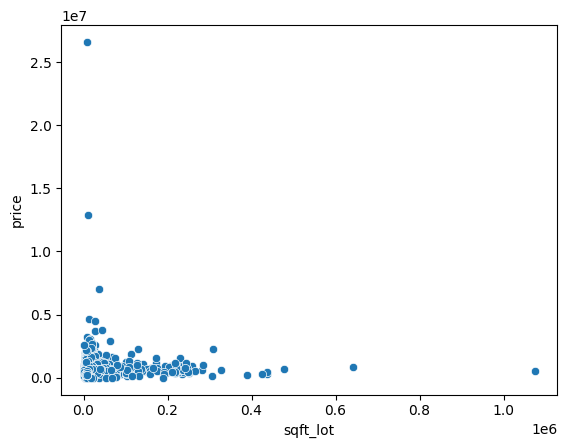

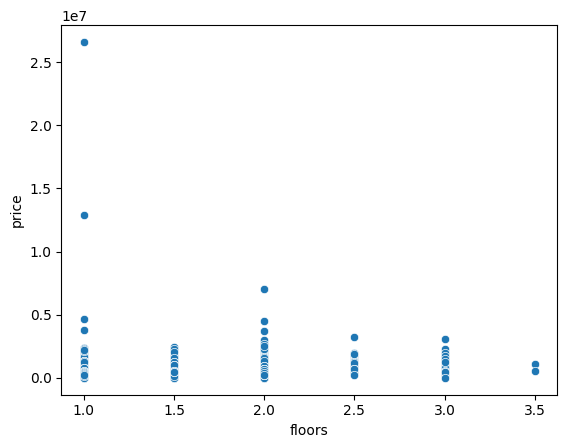

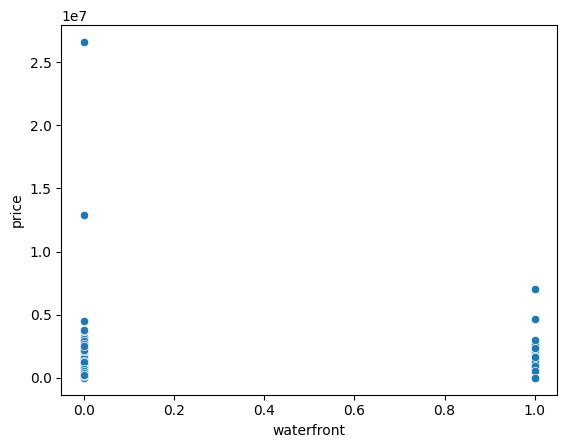

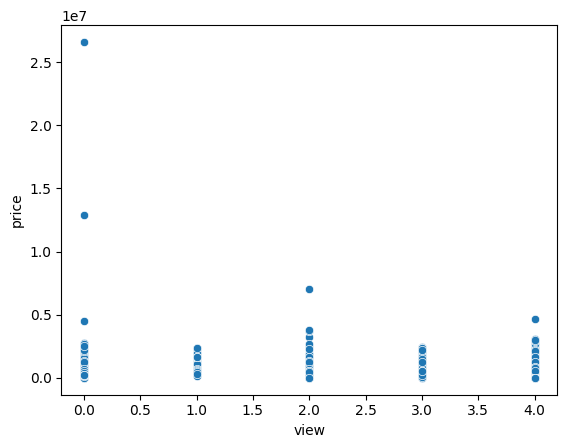

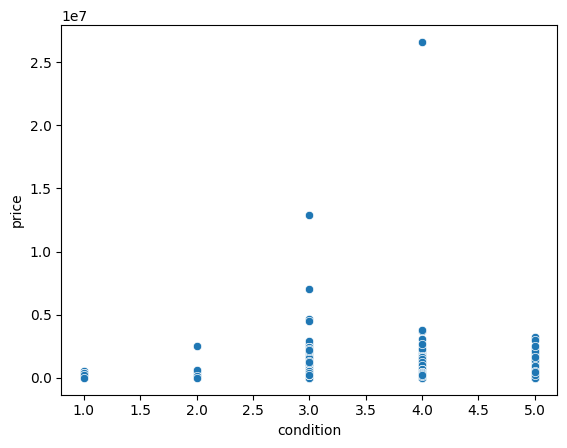

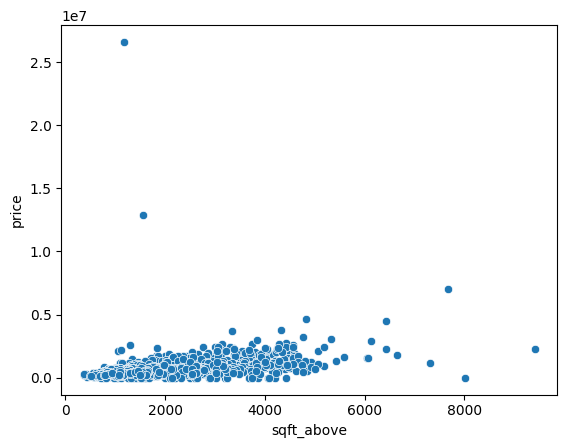

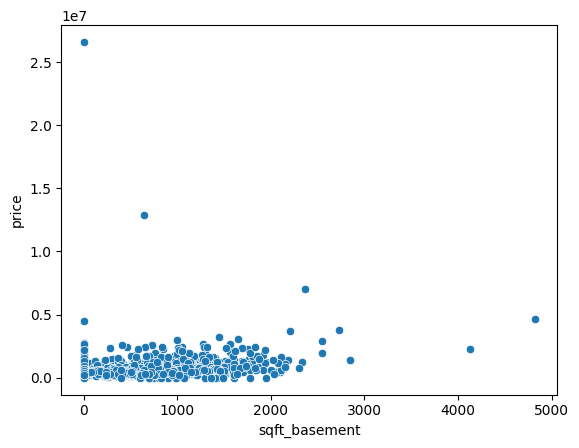

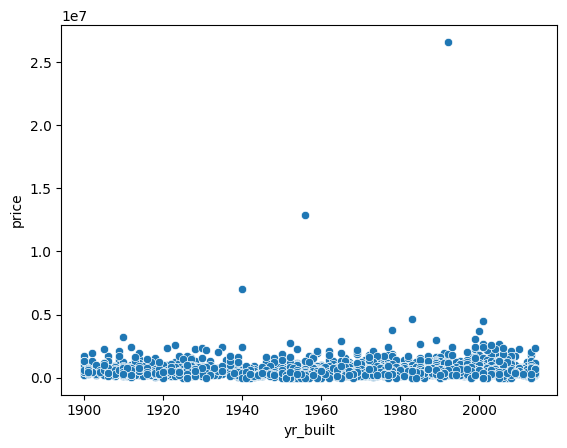

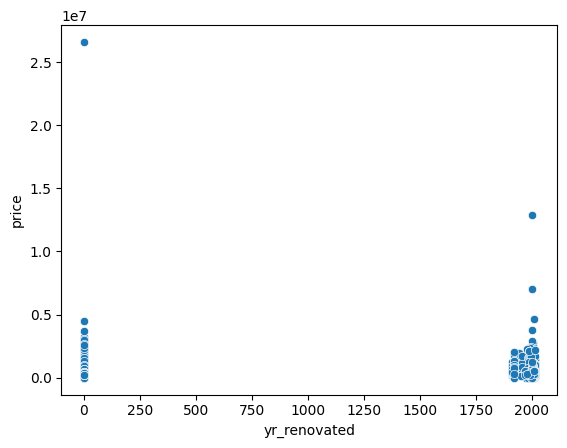

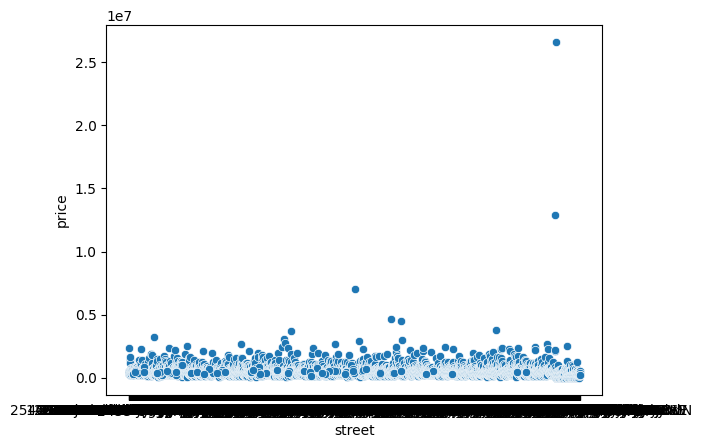

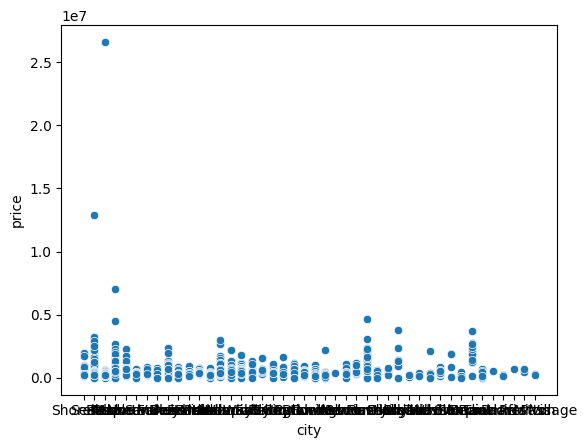

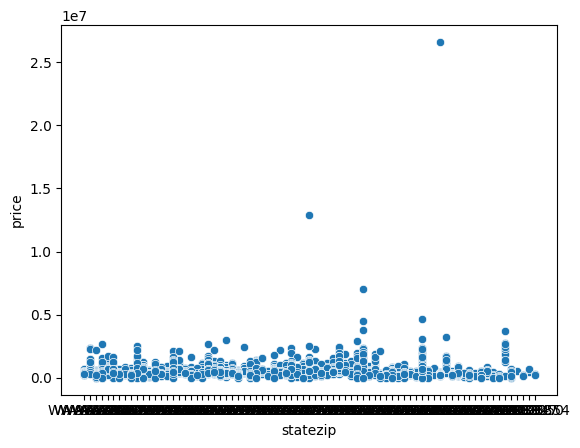

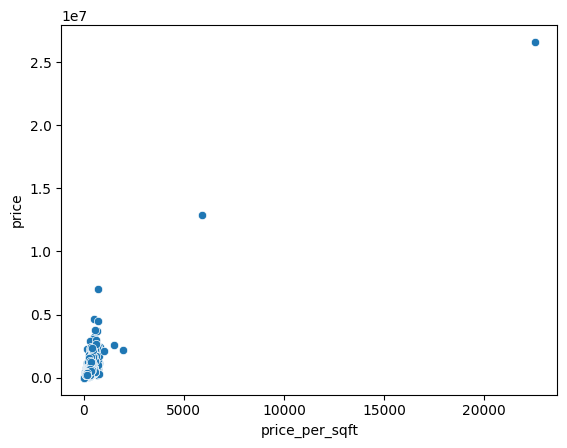

In [22]:
for i in df.columns:
  if i == 'price':
    continue
  sns.scatterplot(data = df, x= i, y='price')

  plt.show()

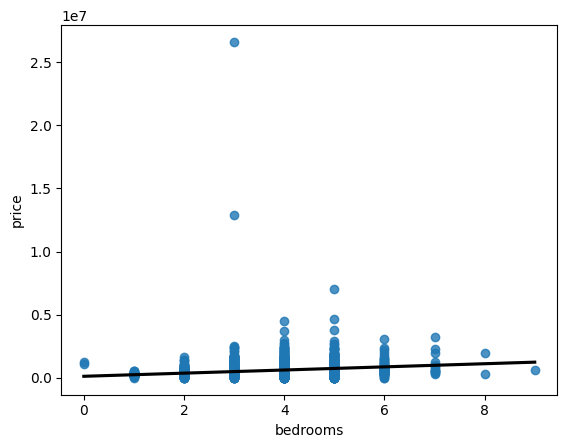

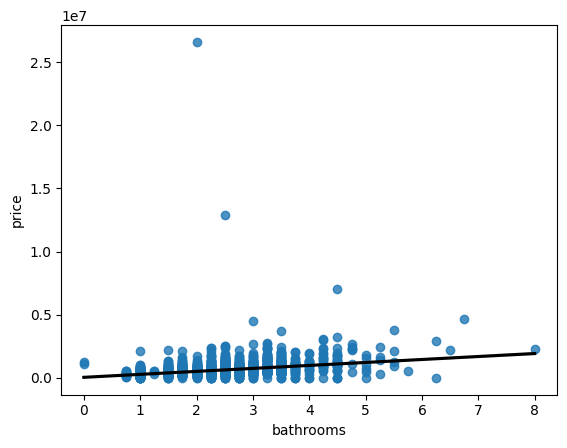

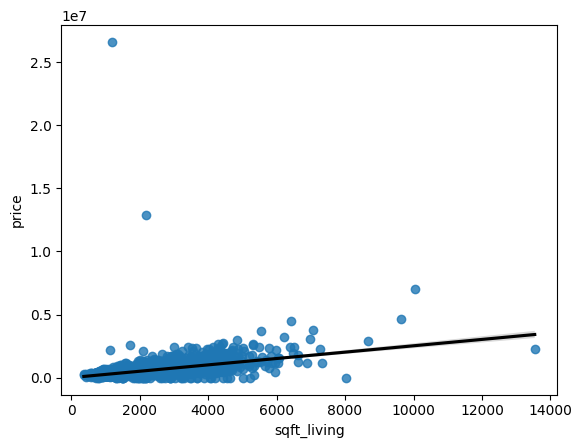

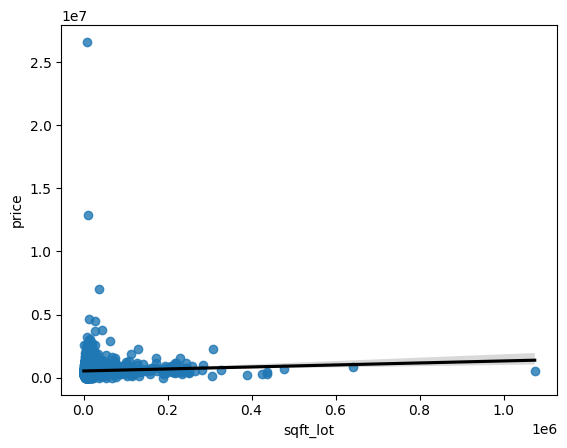

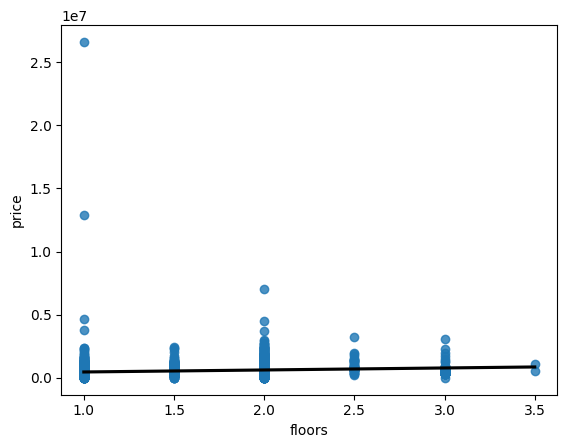

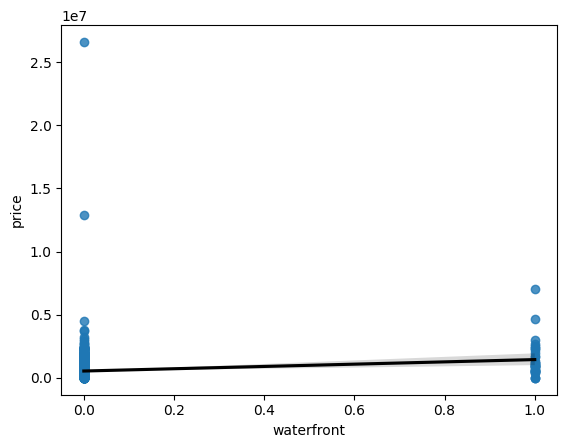

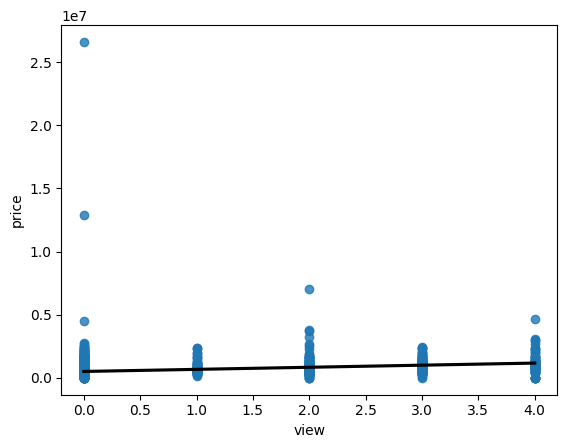

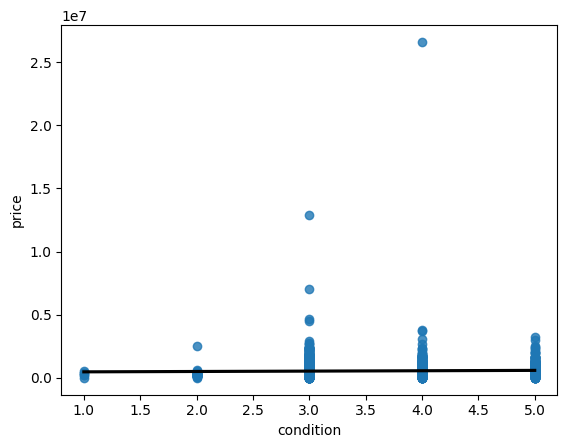

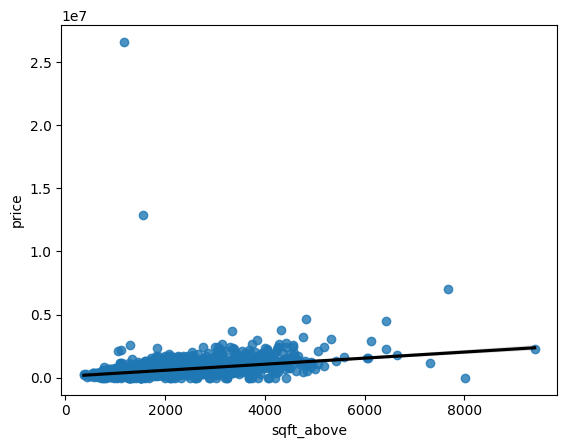

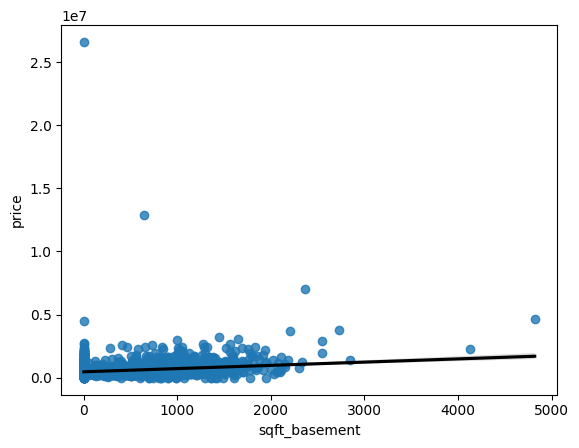

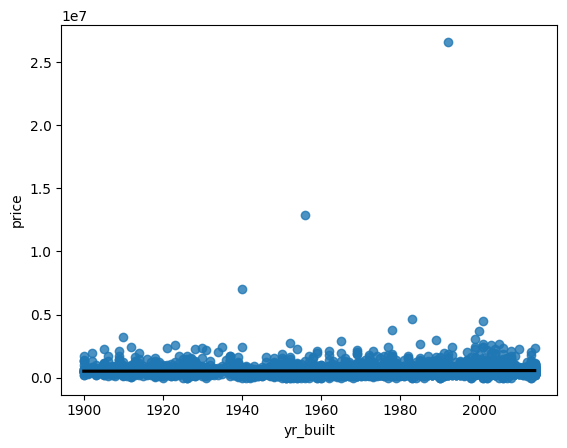

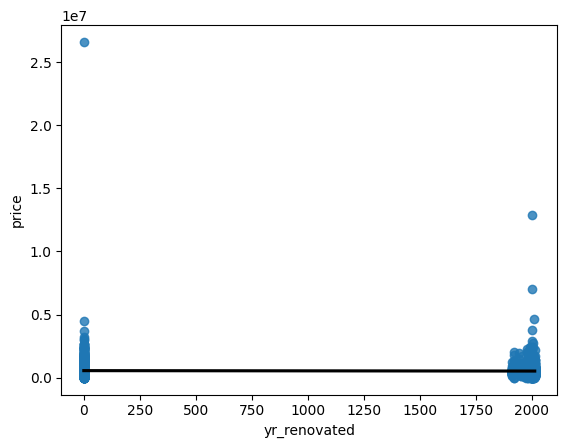

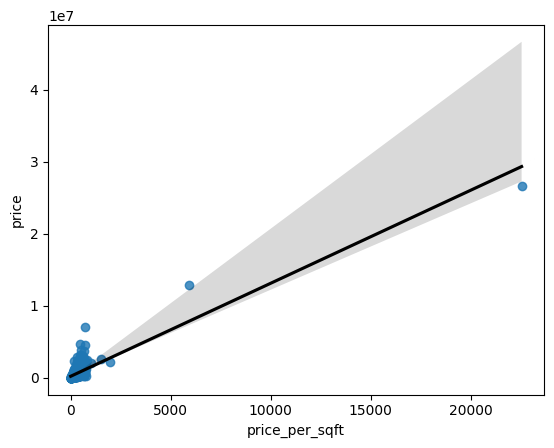

In [23]:
df_numerico = df.select_dtypes(include = ['int64', 'float64'])
for i in df_numerico:
  if i == 'price':
    continue
  sns.regplot(data=df_numerico, x= i , y='price', line_kws={'color': 'black'})
  plt.show()

In [24]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,265.876209
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,357.503362
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,180.817500
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,243.855000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,314.840000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,22533.900000


In [25]:
df['yr_built'].value_counts()

yr_built
2006    111
2005    104
2007     93
2004     92
1978     90
       ... 
1915      6
1935      6
1933      5
1934      4
1936      3
Name: count, Length: 115, dtype: int64

### 1.1 Bivariaveis

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   object 
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   object 
 15  city            4600 non-null   object 
 16  statezip        4600 non-null   object 
 17  price_per_sqft  4600 non-null   f

Text(0.5, 1.0, 'Análise Bivariavel: sqft_living X sqft_basement')

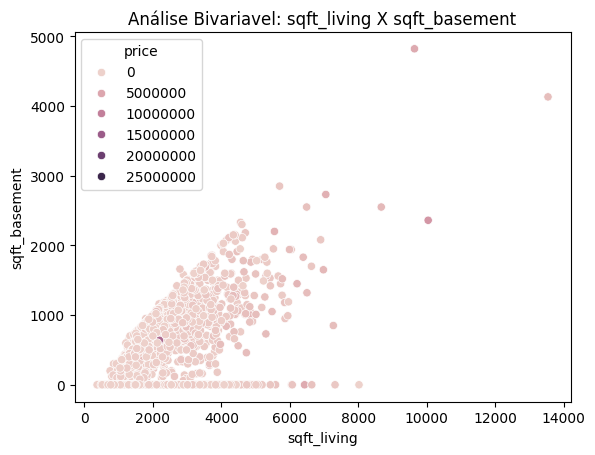

In [27]:
feature_1 = 'sqft_living'
feature_2 = 'sqft_basement'

sns.scatterplot(
    data = df,
    x = feature_1, # variavel 1
    y = feature_2, # variavel 2
    hue='price' # aqui colocamos o target,
)

plt.title(f'Análise Bivariavel: {feature_1} X {feature_2}')

Text(0.5, 1.0, 'Análise Bivariavel: sqft_living X sqft_above')

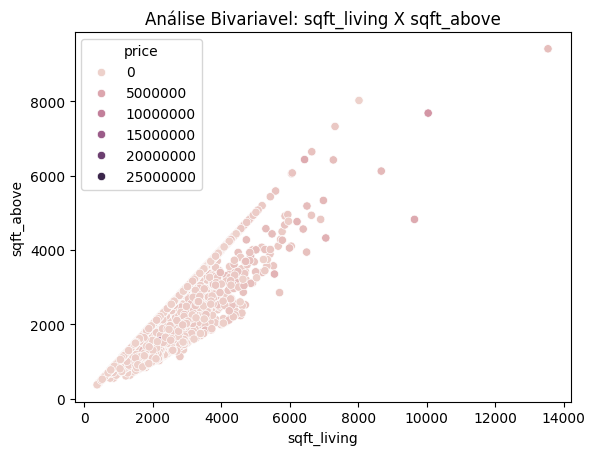

In [28]:
feature_1 = 'sqft_living'
feature_2 = 'sqft_above'

sns.scatterplot(
    data = df,
    x = feature_1, # variavel 1
    y = feature_2, # variavel 2
    hue='price' # aqui colocamos o target,
)

plt.title(f'Análise Bivariavel: {feature_1} X {feature_2}')

Text(0.5, 1.0, 'Análise Bivariavel: sqft_living X sqft_lot')

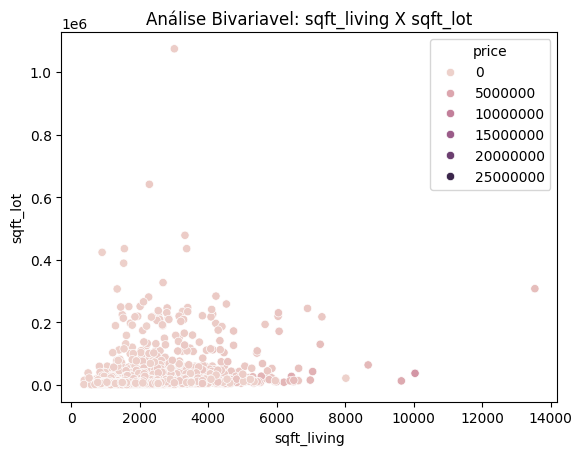

In [29]:
feature_1 = 'sqft_living'
feature_2 = 'sqft_lot'

sns.scatterplot(
    data = df,
    x = feature_1, # variavel 1
    y = feature_2, # variavel 2
    hue='price' # aqui colocamos o target,
)

plt.title(f'Análise Bivariavel: {feature_1} X {feature_2}')

Text(0.5, 1.0, 'Análise Bivariavel: sqft_living X bedrooms')

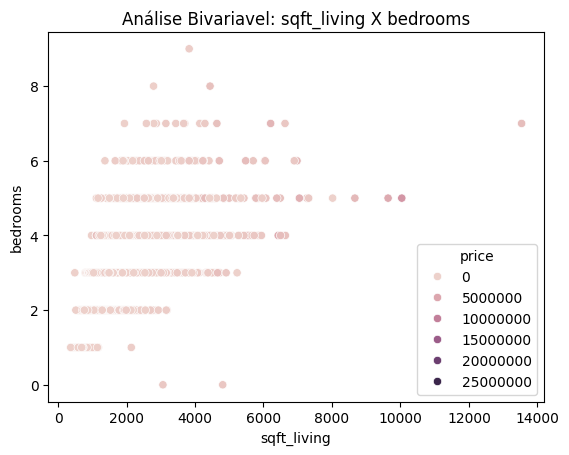

In [30]:
feature_1 = 'sqft_living'
feature_2 = 'bedrooms'

sns.scatterplot(
    data = df,
    x = feature_1, # variavel 1
    y = feature_2, # variavel 2
    hue='price' # aqui colocamos o target,
)

plt.title(f'Análise Bivariavel: {feature_1} X {feature_2}')

Text(0.5, 1.0, 'Análise Bivariavel: bedrooms X bathrooms')

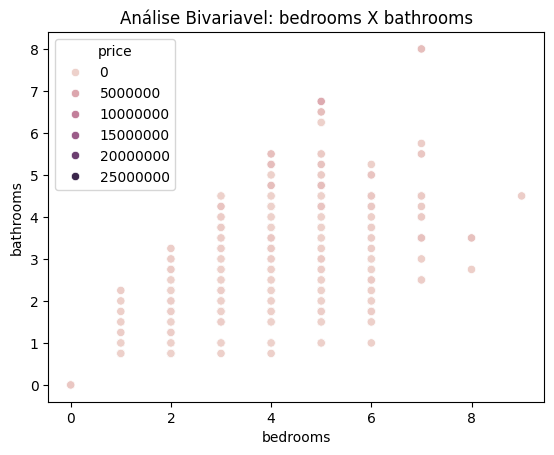

In [31]:
feature_1 = 'bedrooms'
feature_2 = 'bathrooms'

sns.scatterplot(
    data = df,
    x = feature_1, # variavel 1
    y = feature_2, # variavel 2
    hue='price' # aqui colocamos o target,
)

plt.title(f'Análise Bivariavel: {feature_1} X {feature_2}')

Text(0.5, 1.0, 'Análise Bivariavel: sqft_living X bathrooms')

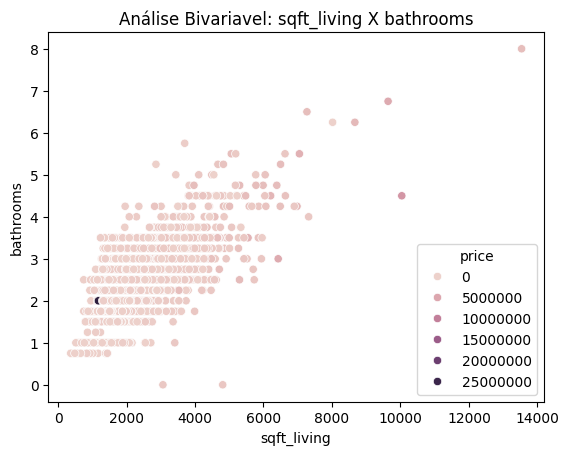

In [32]:
feature_1 = 'sqft_living'
feature_2 = 'bathrooms'

sns.scatterplot(
    data = df,
    x = feature_1, # variavel 1
    y = feature_2, # variavel 2
    hue='price' # aqui colocamos o target,
)

plt.title(f'Análise Bivariavel: {feature_1} X {feature_2}')

---
## 2. Pré-Processamento

In [33]:
from sklearn.model_selection import train_test_split # separacao
from sklearn.preprocessing import OneHotEncoder, StandardScaler # enconder e normalizacao de dados
from sklearn.compose import make_column_transformer #

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   object 
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   object 
 15  city            4600 non-null   object 
 16  statezip        4600 non-null   object 
 17  price_per_sqft  4600 non-null   f

In [35]:
X = df.drop(columns= ['price' , 'price_per_sqft', 'statezip', 'city', 'street', 'date'])
y = df['price']

In [36]:
scaler = StandardScaler()

In [37]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.25)

In [38]:
X_treino_normalizado = scaler.fit_transform(X_treino)
X_teste_normalizado = scaler.transform(X_teste)

---

## 3. Treinamento do modelo

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

In [40]:
regressao_linear = LinearRegression()
knn = KNeighborsRegressor()

In [41]:
regressao_linear.fit(X_treino_normalizado, y_treino)
knn.fit(X_treino_normalizado, y_treino)

print(f'score de treino Regressão Linear: {regressao_linear.score(X_treino_normalizado, y_treino)}')
print(f'score de treino KNN {knn.score(X_treino_normalizado, y_treino)}')

score de treino Regressão Linear: 0.21901511161556453
score de treino KNN 0.4045689129088553


Na regressão linear não temos uma "acurácia", pois o modelo teria que acertar o valor preciso.

Nesse caso temos o **R²**, essa métrica responde o quanto nosso modelo consegue explicar os dados.

Quanto melhor o meu modelo é em explicar a variação dos dados comparado a simplesmente usar a média?

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

In [42]:
print(f'score de teste Regressão Linear: {regressao_linear.score(X_teste_normalizado, y_teste)}')
print(f'score de teste KNN {knn.score(X_teste_normalizado, y_teste)}')

score de teste Regressão Linear: 0.20730109940971198
score de teste KNN 0.1652677481815028


In [43]:
X_teste_normalizado = pd.DataFrame(X_teste_normalizado)
y_teste = pd.DataFrame(y_teste)

In [44]:
X_teste_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1150 entries, 0 to 1149
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1150 non-null   float64
 1   1       1150 non-null   float64
 2   2       1150 non-null   float64
 3   3       1150 non-null   float64
 4   4       1150 non-null   float64
 5   5       1150 non-null   float64
 6   6       1150 non-null   float64
 7   7       1150 non-null   float64
 8   8       1150 non-null   float64
 9   9       1150 non-null   float64
 10  10      1150 non-null   float64
 11  11      1150 non-null   float64
dtypes: float64(12)
memory usage: 107.9 KB


In [45]:
y_teste.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1150 entries, 913 to 1270
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   1150 non-null   float64
dtypes: float64(1)
memory usage: 18.0 KB


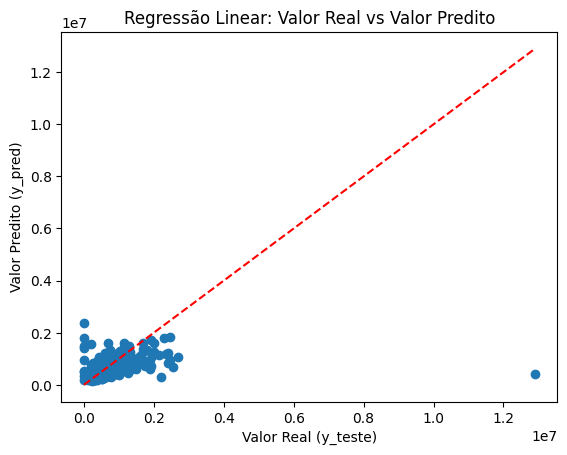

In [46]:
y_pred = knn.predict(X_teste_normalizado)

plt.scatter(y_teste, y_pred)
plt.plot([y_teste.min().min(), y_teste.max().max()], [y_teste.min().min(), y_teste.max().max()], color='red', linestyle='--')

plt.xlabel('Valor Real (y_teste)')
plt.ylabel('Valor Predito (y_pred)')
plt.title('Regressão Linear: Valor Real vs Valor Predito')
plt.show()